In [1]:
#TO DO funzioni che si ripetono 
#from utils import pairs_generations

import torch
import numpy as np
import random
import os
import tarfile
from nats_bench import create
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from dataset_loader import NASDatasetFactory
from model import VAE,vae_accuracy_loss,vae_loss,FlowNet,flow_loss
from torch.utils.data import Subset, DataLoader
import torch
from utils import build_accuracy_pairs, generate_archs,decoded_x_to_nas201_arch, query_nas201_accuracy,train_one_epoch, arch_to_tensor, compare_accuracy_distributions, pretrain_and_freeze_vae

In [2]:
#for reproducibility
seed = 42

# Python random
random.seed(seed)

# NumPy
np.random.seed(seed)

# PyTorch CPU
torch.manual_seed(seed)

# PyTorch GPU (se usi CUDA)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# per riproducibilità più forte (può rallentare)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
DATASET_NAME = "NAS201"


In [4]:
if DATASET_NAME == "NAS201":
    # ── PATH CONFIG ──────────────────────────────────────────────────────────
    # Questo notebook sta in progetto-deeplearning/latent_space/
    # I dataset stanno in progetto-deeplearning/datasets/
    BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
    DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

    percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
    DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

    # Estrazione archivio (solo la prima volta)
    if not os.path.exists(DATASET_PATH):
        print('Estrazione in corso...')
        with tarfile.open(percorso_tar, 'r') as tar:
            tar.extractall(path=DATASETS_DIR)
        print('Estrazione completata!')
    else:
        print('Dataset già estratto.')

    # Caricamento API NATS-Bench TSS
    api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
    print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


## Data loading 

In [7]:

# 2. Crea dataset Torch da NAS201
dataset = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",      # puoi mettere anche "cifar100" o "imagenet16-120"
    metric="test-accuracy",
    flatten=True,
    normalize_y=True,
)

# 3. Test base
print("Numero architetture:", len(dataset))

x0, y0 = dataset[0]
print("x0 shape:", x0.shape)
print("y0:", y0)
print("y0 shape:", y0.shape)

# 4. Split train/test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Numero architetture: 15625
x0 shape: torch.Size([96])
y0: tensor(0.6955)
y0 shape: torch.Size([])
Train size: 12500
Test size: 3125


## TO DO flow direction: 

## Analyzing 1 epoch of Training:

1. VAE TRAINING ON FIRST RANDOMLY GENERATED SET OF ARCHITECTURES

In [6]:

DEVICE = "cpu"   

N = 256
vae_epochs = 200
beta = 0

# 1. Genera 256 architetture random da NAS201 train
train_loader = generate_archs(
    dataset=train_dataset,
    N=N
)

# 2. Crea VAE
model = VAE().to(DEVICE)

vae_optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# 3. Training VAE sui 256 esempi
model.train()

for epoch in range(vae_epochs):

    total_loss = 0.0

    for x, y in train_loader:

        x = x.to(DEVICE).float()

        # forward
        recon, mu, logvar, pred_acc = model(x)

        # uso SOLO la vae_loss
        loss = vae_loss(
            recon=recon,
            x=x,
            mu=mu,
            logvar=logvar,
            beta=beta
        )

        # backward
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"loss={total_loss:.4f}"
        )

Epoch 000 | loss=0.9883
Epoch 005 | loss=0.4296
Epoch 010 | loss=0.2366
Epoch 015 | loss=0.2084
Epoch 020 | loss=0.2048
Epoch 025 | loss=0.2028
Epoch 030 | loss=0.2027
Epoch 035 | loss=0.2028
Epoch 040 | loss=0.2015
Epoch 045 | loss=0.2018
Epoch 050 | loss=0.2014
Epoch 055 | loss=0.2008
Epoch 060 | loss=0.2003
Epoch 065 | loss=0.1993
Epoch 070 | loss=0.1986
Epoch 075 | loss=0.1956
Epoch 080 | loss=0.1886
Epoch 085 | loss=0.1855
Epoch 090 | loss=0.1829
Epoch 095 | loss=0.1769
Epoch 100 | loss=0.1700
Epoch 105 | loss=0.1653
Epoch 110 | loss=0.1547
Epoch 115 | loss=0.1425
Epoch 120 | loss=0.1317
Epoch 125 | loss=0.1217
Epoch 130 | loss=0.1119
Epoch 135 | loss=0.1033
Epoch 140 | loss=0.0968
Epoch 145 | loss=0.0905
Epoch 150 | loss=0.0832
Epoch 155 | loss=0.0788
Epoch 160 | loss=0.0734
Epoch 165 | loss=0.0701
Epoch 170 | loss=0.0663
Epoch 175 | loss=0.0633
Epoch 180 | loss=0.0595
Epoch 185 | loss=0.0558
Epoch 190 | loss=0.0527
Epoch 195 | loss=0.0498


2. LATENT SPACE EMBEDDING EXTRACTION

In [7]:
model.eval()

z_all = []
y_all = []

with torch.no_grad():
    for x, y in train_loader:

        x = x.to(DEVICE).float()
        y = y.float().view(-1)

        mu, logvar = model.encode(x)

        z_all.append(mu.cpu())
        y_all.append(y.cpu())

z_all = torch.cat(z_all, dim=0)
y_all = torch.cat(y_all, dim=0)

print("z_all shape:", z_all.shape)
print("y_all shape:", y_all.shape)

print("y min:", y_all.min().item())
print("y max:", y_all.max().item())
print("y mean:", y_all.mean().item())

z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
y min: 0.10000000149011612
y max: 0.8824999928474426
y mean: 0.7599554061889648


3. PAIRS GENERATION FOR FLOW MATCHING 

In [8]:
pairs_x, pairs_target, pairs_info = build_accuracy_pairs(
    X=z_all,
    y=y_all,
    K=50,
    min_delta_acc=0.0,
    seed=42
)

print("pairs_x shape:", pairs_x.shape)
print("pairs_target shape:", pairs_target.shape)
print("numero coppie:", len(pairs_x))

for info in pairs_info[:10]:
    print(info)

pairs_x shape: torch.Size([254, 16])
pairs_target shape: torch.Size([254, 16])
numero coppie: 254
{'i': 0, 'j': 101, 'acc_i': 0.7851000428199768, 'acc_j': 0.8349999785423279, 'delta_acc': 0.049899935722351074, 'distance': 12.685928344726562}
{'i': 1, 'j': 114, 'acc_i': 0.6101999878883362, 'acc_j': 0.6879000067710876, 'delta_acc': 0.07770001888275146, 'distance': 20.207971572875977}
{'i': 2, 'j': 121, 'acc_i': 0.7830999493598938, 'acc_j': 0.8012999892234802, 'delta_acc': 0.018200039863586426, 'distance': 19.192228317260742}
{'i': 3, 'j': 104, 'acc_i': 0.7430000305175781, 'acc_j': 0.8330000042915344, 'delta_acc': 0.0899999737739563, 'distance': 19.521089553833008}
{'i': 4, 'j': 29, 'acc_i': 0.8564000129699707, 'acc_j': 0.8616999983787537, 'delta_acc': 0.005299985408782959, 'distance': 16.819393157958984}
{'i': 5, 'j': 6, 'acc_i': 0.10000000149011612, 'acc_j': 0.8419000506401062, 'delta_acc': 0.7419000267982483, 'distance': 18.310195922851562}
{'i': 6, 'j': 45, 'acc_i': 0.8419000506401062

In [9]:
target_mean = pairs_target.mean(dim=0, keepdim=True)
target_std = pairs_target.std(dim=0, keepdim=True) + 1e-8


4. FLOW TRAINING 

In [10]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

if len(pairs_x) == 0:
    print("Nessuna coppia trovata: prova ad aumentare K o abbassare min_delta_acc.")
else:
    pairs_dataset = TensorDataset(pairs_x, pairs_target)

    pairs_loader = DataLoader(
        pairs_dataset,
        batch_size=64,
        shuffle=True
    )

    flow = FlowNet(dim=16).to(DEVICE)

    flow_optimizer = torch.optim.Adam(
        flow.parameters(),
        lr=1e-3
    )

    flow_epochs = 100

    flow.train()

    for epoch in range(flow_epochs):

        total_flow_loss = 0.0

        for z_start, direction_target in pairs_loader:

            z_start = z_start.to(DEVICE).float()
            direction_target = direction_target.to(DEVICE).float()

            pred_direction = flow(z_start)

            loss = F.mse_loss(pred_direction, direction_target)

            flow_optimizer.zero_grad()
            loss.backward()
            flow_optimizer.step()

            total_flow_loss += loss.item()

        if epoch % 10 == 0:
            print(
                f"Flow epoch {epoch:03d} | "
                f"loss={total_flow_loss:.6f}"
            )

Flow epoch 000 | loss=85.313229
Flow epoch 010 | loss=61.966290
Flow epoch 020 | loss=56.602570
Flow epoch 030 | loss=53.146610
Flow epoch 040 | loss=50.667446
Flow epoch 050 | loss=48.251090
Flow epoch 060 | loss=46.072185
Flow epoch 070 | loss=43.941680
Flow epoch 080 | loss=42.008126
Flow epoch 090 | loss=39.775006


In [11]:
print("pairs_x shape:", pairs_x.shape)
print("pairs_target shape:", pairs_target.shape)

print("target min:", pairs_target.min().item())
print("target max:", pairs_target.max().item())
print("target mean:", pairs_target.mean().item())
print("target std:", pairs_target.std().item())

target_norm = torch.norm(pairs_target, dim=1)
print("target norm mean:", target_norm.mean().item())
print("target norm std:", target_norm.std().item())
print("target norm min:", target_norm.min().item())
print("target norm max:", target_norm.max().item())

pairs_x shape: torch.Size([254, 16])
pairs_target shape: torch.Size([254, 16])
target min: -15.086148262023926
target max: 14.205394744873047
target mean: 0.11887215822935104
target std: 4.554905414581299
target norm mean: 17.982858657836914
target norm std: 2.9580881595611572
target norm min: 8.799053192138672
target norm max: 25.73885154724121


5. GENERATING NEW ARCHITECTURES FROM FLOW DIRECTION 

In [12]:
flow.eval()

alpha = 0.5

with torch.no_grad():

    z_start = z_all.to(DEVICE).float()

    direction = flow(z_start)

    z_new = z_start + alpha * direction

print("z_new shape:", z_new.shape)

z_new shape: torch.Size([256, 16])


6. DECODING ARCHITECTURES 

In [13]:
model.eval()

with torch.no_grad():
    x_new = model.decode(z_new)
    new_archs = []
    new_accs = []
    new_infos = []

    for i in range(x_new.shape[0]):

        arch_str = decoded_x_to_nas201_arch(x_new[i])

        acc, info = query_nas201_accuracy(
            api=api,
            arch_str=arch_str,
            dataset_name="cifar10",
            hp="200",
            metric="test-accuracy"
        )

        new_archs.append(arch_str)
        new_accs.append(acc)
        new_infos.append(info)

    print("Prime architetture generate:")

    for i in range(min(10, len(new_archs))):
        print(i)
        print("arch:", new_archs[i])
        print("acc:", new_accs[i])
        print()

print("x_new shape:", x_new.shape)
print("x_new min:", x_new.min().item())
print("x_new max:", x_new.max().item())

Prime architetture generate:
0
arch: |none~0|+|nor_conv_3x3~0|none~1|+|skip_connect~0|avg_pool_3x3~1|none~2|
acc: 86.48

1
arch: |none~0|+|nor_conv_3x3~0|nor_conv_3x3~1|+|nor_conv_3x3~0|avg_pool_3x3~1|none~2|
acc: 92.03

2
arch: |skip_connect~0|+|skip_connect~0|nor_conv_1x1~1|+|nor_conv_1x1~0|none~1|skip_connect~2|
acc: 89.43666666666667

3
arch: |avg_pool_3x3~0|+|nor_conv_1x1~0|nor_conv_3x3~1|+|avg_pool_3x3~0|nor_conv_1x1~1|nor_conv_1x1~2|
acc: 90.815

4
arch: |skip_connect~0|+|nor_conv_3x3~0|nor_conv_1x1~1|+|nor_conv_3x3~0|none~1|skip_connect~2|
acc: 92.60666666666668

5
arch: |none~0|+|none~0|avg_pool_3x3~1|+|nor_conv_1x1~0|none~1|avg_pool_3x3~2|
acc: 88.925

6
arch: |none~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|avg_pool_3x3~2|
acc: 91.185

7
arch: |nor_conv_3x3~0|+|nor_conv_3x3~0|skip_connect~1|+|skip_connect~0|nor_conv_1x1~1|avg_pool_3x3~2|
acc: 93.26666666666667

8
arch: |none~0|+|nor_conv_3x3~0|nor_conv_1x1~1|+|skip_connect~0|avg_pool_3x3~1|nor_conv_3x3

In [14]:
print("z_all std media:", z_all.std(dim=0).mean().item())
print("z_new std media:", z_new.std(dim=0).mean().item())
print("x_new std media:", x_new.std(dim=0).mean().item())

print("x_new min:", x_new.min().item())
print("x_new max:", x_new.max().item())

print("Prime differenze tra decoded:")
print(torch.abs(x_new[0] - x_new[1]).mean().item())
print(torch.abs(x_new[0] - x_new[2]).mean().item())

z_all std media: 4.678967475891113
z_new std media: 3.6175060272216797
x_new std media: 0.0922619104385376
x_new min: 6.114338849446786e-26
x_new max: 0.9999998807907104
Prime differenze tra decoded:
0.04793946072459221
0.10699731111526489


### comparing accuracies

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1. Converto le accuracy generate
# -----------------------------

new_accs_array = np.array(
    [a for a in new_accs if a is not None],
    dtype=np.float32
)

print("Numero accuracy valide generate:", len(new_accs_array))

# y_all iniziale
y_initial = y_all.detach().cpu().numpy().reshape(-1).astype(np.float32)

print("y_initial min/max:", y_initial.min(), y_initial.max())
print("new_accs min/max:", new_accs_array.min(), new_accs_array.max())

Numero accuracy valide generate: 256
y_initial min/max: 0.1 0.8825
new_accs min/max: 10.0 93.98


INITIAL    — n= 256  mean=75.996  var=179.194  std=13.386  min=10.000  max=88.250
GENERATED  — n= 256  mean=89.123  var=77.468  std=8.802  min=10.000  max=93.980
Δ mean = +13.127


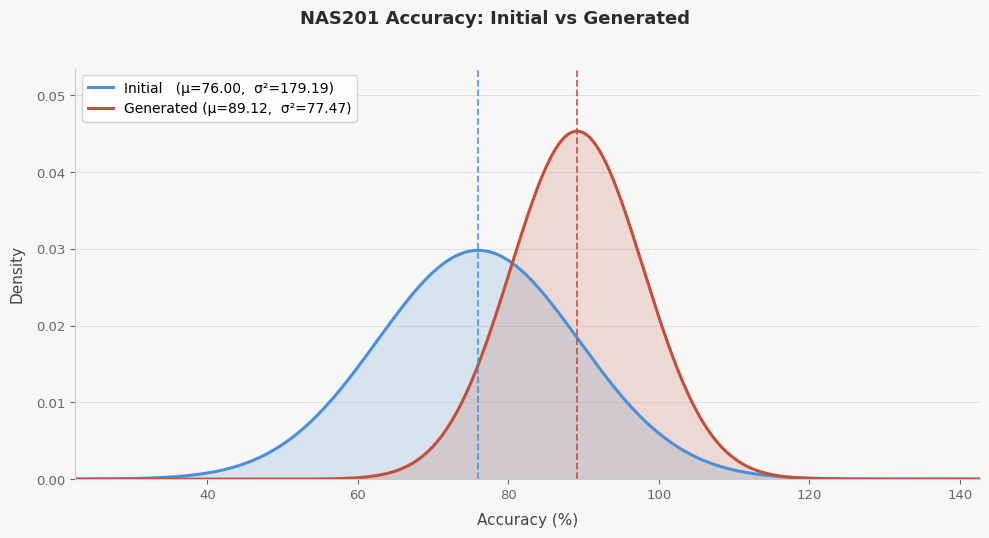

In [16]:
compare_accuracy_distributions(y_all, new_accs)

## TRAINING LOOP 

**allenamento**
1. allenare ogni volta VAE **provato**
2. early stopping per VAE **provato**
3. congelamento VAE dopo pretrain **provato**
4. VAE con accuracy loss
5. traiettoria flow dopo training **provato**

**per la diversità**

2. elite + diverse + random injection
3. introdurre rumore quando si campiona dal flow
4. alpha non troppo alto, tipo 0.2 o 0.3
5. grafico per capire quanto esplora

si potrebbe tenere sotto controllo la diversità generata, se questa scende sotto tot si aggiunge diversità artificiale

In [61]:
outer_epochs = 20
LATENT_DIM = 16
model_VAE = VAE().to(DEVICE)
flow = FlowNet(dim=LATENT_DIM)
N = 256
vae_epochs = 200

early_stopping = True
freeze_vae = True
beta = 0

pretrain_vae_epochs = 300
flow_epochs = 200
pretrain_batch_size = 128
alpha = 0.5

In [62]:
pretrain_fraction = 0.1  
pretrain_seed = 42       

if freeze_vae:

    print("Pretraining VAE before outer loop...")

    # --------------------------------------------------
    # Prendo solo una frazione del train_dataset
    # --------------------------------------------------
    n_total = len(train_dataset)
    n_pretrain = int(n_total * pretrain_fraction)

    generator = torch.Generator().manual_seed(pretrain_seed)

    indices = torch.randperm(
        n_total,
        generator=generator
    )[:n_pretrain].tolist()

    pretrain_subset = Subset(
        train_dataset,
        indices
    )

    print(f"VAE pretrain subset: {n_pretrain} / {n_total} architectures")

    pretrain_loader = DataLoader(
        pretrain_subset,
        batch_size=pretrain_batch_size,
        shuffle=True
    )

    model_VAE = pretrain_and_freeze_vae(
        model_VAE=model_VAE,
        pretrain_loader=pretrain_loader,
        beta=beta,
        vae_epochs=pretrain_vae_epochs,
        DEVICE=DEVICE,
        early_stop=early_stopping,
        patience=20,
        min_delta=1e-5,
        loss_threshold=1e-4,
        lr=1e-3
    )

Pretraining VAE before outer loop...
VAE pretrain subset: 1250 / 12500 architectures
VAE pretrain epoch 000 | loss=0.235658
VAE pretrain epoch 010 | loss=0.050683
VAE pretrain epoch 020 | loss=0.050324
VAE pretrain epoch 030 | loss=0.048985
VAE pretrain epoch 040 | loss=0.045239
VAE pretrain epoch 050 | loss=0.034587
VAE pretrain epoch 060 | loss=0.027403
VAE pretrain epoch 070 | loss=0.022652
VAE pretrain epoch 080 | loss=0.017137
VAE pretrain epoch 090 | loss=0.014714
VAE pretrain epoch 100 | loss=0.012352
VAE pretrain epoch 110 | loss=0.010021
VAE pretrain epoch 120 | loss=0.008757
VAE pretrain epoch 130 | loss=0.007717
VAE pretrain epoch 140 | loss=0.006940
VAE pretrain epoch 150 | loss=0.006600
VAE pretrain epoch 160 | loss=0.006168
VAE pretrain epoch 170 | loss=0.005896
VAE pretrain epoch 180 | loss=0.005696
VAE pretrain epoch 190 | loss=0.005518
VAE pretrain epoch 200 | loss=0.005402
VAE pretrain epoch 210 | loss=0.005242
VAE pretrain epoch 220 | loss=0.005177
VAE pretrain epoch

In [63]:
history = {
    "epoch": [],
    "mean_acc": [],
    "std_acc": [],
    "min_acc": [],
    "max_acc": [],
    "num_valid_archs": [],
}

# Pool iniziale
train_loader = generate_archs(
    dataset=train_dataset,
    N=N
)

for outer_epoch in range(outer_epochs):

    print(f"\n========== OUTER EPOCH {outer_epoch + 1}/{outer_epochs} ==========")

    # 1. Train VAE + flow sul pool corrente
    result = train_one_epoch(
        flow=flow,
        model_VAE=model_VAE,
        train_loader=train_loader,
        beta=beta,
        vae_epochs=vae_epochs,
        flow_epochs=flow_epochs,
        alpha=alpha,
        DEVICE=DEVICE,

        # VAE training control
        train_vae=not freeze_vae,
        early_stop=early_stopping,
        patience=15,
        min_delta=1e-5,
        loss_threshold=1e-4
    )

    if result is None:
        print("Training interrotto: nessuna coppia valida trovata.")
        break

    z_new, z_all, y_all, pairs_info = result

    # --------------------------------------------------
    # 2. Decodifica z_new in nuove architetture
    # --------------------------------------------------
    model_VAE.eval()

    with torch.no_grad():
        decoded_batch = model_VAE.decode(
            z_new.to(DEVICE).float()
        )

    decoded_batch = decoded_batch.detach().cpu()

    # --------------------------------------------------
    # 3. Da decoded x a stringhe architettura NAS201
    # --------------------------------------------------
    new_archs = []
    new_accs = []
    new_infos = []

    for x_decoded in decoded_batch:

        arch_str = decoded_x_to_nas201_arch(x_decoded)

        acc, info = query_nas201_accuracy(
            api=api,
            arch_str=arch_str
        )

        # Se l'architettura non è valida o la API non restituisce accuracy, la salto
        if acc is None:
            continue

        new_archs.append(arch_str)
        new_accs.append(acc)
        new_infos.append(info)

    if len(new_archs) == 0:
        print("Nessuna architettura valida generata dal flow.")
        break

    new_accs = torch.tensor(new_accs).float() / 100.0

    # --------------------------------------------------
    # 4. Statistiche accuracy delle architetture generate
    # --------------------------------------------------
    mean_acc = new_accs.mean().item()
    std_acc = new_accs.std().item()
    min_acc = new_accs.min().item()
    max_acc = new_accs.max().item()

    print("Generated NAS201 architectures:")
    print(f"valid archs = {len(new_archs)} / {len(decoded_batch)}")
    print(f"mean acc    = {mean_acc:.4f}")
    print(f"std acc     = {std_acc:.4f}")
    print(f"min acc     = {min_acc:.4f}")
    print(f"max acc     = {max_acc:.4f}")

    history["epoch"].append(outer_epoch)
    history["mean_acc"].append(mean_acc)
    history["std_acc"].append(std_acc)
    history["min_acc"].append(min_acc)
    history["max_acc"].append(max_acc)
    history["num_valid_archs"].append(len(new_archs))

    # --------------------------------------------------
    # 5. Ricostruisci il train_loader per la prossima outer epoch
    # --------------------------------------------------
    X_next = []

    for arch_str in new_archs:
        x = arch_to_tensor(arch_str)
        x = torch.from_numpy(x).float().view(-1)
        X_next.append(x)

    X_next = torch.stack(X_next)
    y_next = new_accs.float().view(-1)

    train_loader = DataLoader(
        TensorDataset(X_next, y_next),
        batch_size=64,
        shuffle=True
    )



========== OUTER EPOCH 1/20 ==========
Skipping VAE training: using frozen/pretrained VAE.
z_all shape: torch.Size([256, 16])
y_all shape: torch.Size([256])
pairs_x shape: torch.Size([253, 16])
pairs_target shape: torch.Size([253, 16])
Flow epoch 000 | loss=176.995705
Flow epoch 010 | loss=126.972658
Flow epoch 020 | loss=111.748154
Flow epoch 030 | loss=104.947029
Flow epoch 040 | loss=98.423235
Flow epoch 050 | loss=93.062101
Flow epoch 060 | loss=87.465410
Flow epoch 070 | loss=82.568808
Flow epoch 080 | loss=77.684666
Flow epoch 090 | loss=74.169846
Flow epoch 100 | loss=69.616470
Flow epoch 110 | loss=66.618201
Flow epoch 120 | loss=63.230029
Flow epoch 130 | loss=60.420000
Flow epoch 140 | loss=57.365985
Flow epoch 150 | loss=53.586106
Flow epoch 160 | loss=50.820916
Flow epoch 170 | loss=48.227121
Flow epoch 180 | loss=46.200813
Flow epoch 190 | loss=44.063703
z_new shape: torch.Size([256, 16])
Generated NAS201 architectures:
valid archs = 256 / 256
mean acc    = 0.8613
std acc

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm


def plot_history_gaussians(
    history,
    title="NAS201 Accuracy distributions across outer epochs",
    save_path=None,
    max_gaussians=5
):
    epochs = np.array(history["epoch"])
    means = np.array(history["mean_acc"], dtype=np.float32)
    stds = np.array(history["std_acc"], dtype=np.float32)

    if len(means) == 0:
        raise ValueError("history è vuoto: non ci sono epoche da plottare.")

    # Se ci sono più epoche di max_gaussians, ne seleziono solo alcune,
    # distribuite uniformemente tra inizio e fine.
    if len(means) > max_gaussians:
        selected_idx = np.linspace(
            0,
            len(means) - 1,
            max_gaussians,
            dtype=int
        )
    else:
        selected_idx = np.arange(len(means))

    epochs_plot = epochs[selected_idx]
    means_plot = means[selected_idx]
    stds_plot = stds[selected_idx]

    # Nel tuo ciclo hai già fatto /100, quindi mean/std sono in [0, 1].
    # Qui le porto in percentuale solo per il grafico.
    means_plot = means_plot * 100.0
    stds_plot = stds_plot * 100.0

    # Evita problemi se una std è zero
    stds_plot = np.maximum(stds_plot, 1e-6)

    # Asse x comune calcolato SOLO sulle gaussiane selezionate
    x_min = np.min(means_plot - 4 * stds_plot)
    x_max = np.max(means_plot + 4 * stds_plot)

    xs = np.linspace(x_min, x_max, 1000)

    BG = "#F7F7F5"

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_edgecolor("#CCCCCC")
    ax.spines["bottom"].set_edgecolor("#CCCCCC")

    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(means_plot)))

    max_pdf = 0.0

    for epoch, mu, std, color in zip(epochs_plot, means_plot, stds_plot, colors):
        pdf = norm.pdf(xs, mu, std)
        max_pdf = max(max_pdf, pdf.max())

        ax.fill_between(xs, pdf, alpha=0.10, color=color)

        ax.plot(
            xs,
            pdf,
            color=color,
            linewidth=2.0,
            label=f"Epoch {epoch + 1} (μ={mu:.2f}, σ={std:.2f})"
        )

        ax.axvline(
            mu,
            color=color,
            linewidth=1.1,
            linestyle="--",
            alpha=0.75
        )

    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.6, linestyle="-", zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel("Accuracy (%)", fontsize=11, labelpad=8, color="#444444")
    ax.set_ylabel("Density", fontsize=11, labelpad=8, color="#444444")
    ax.tick_params(colors="#666666", labelsize=9.5)

    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(bottom=0, top=max_pdf * 1.18)

    ax.legend(
        fontsize=9,
        framealpha=0.85,
        edgecolor="#CCCCCC",
        loc="upper left",
        handlelength=1.8
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
        y=0.97,
        color="#2C2C2A"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=160,
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()

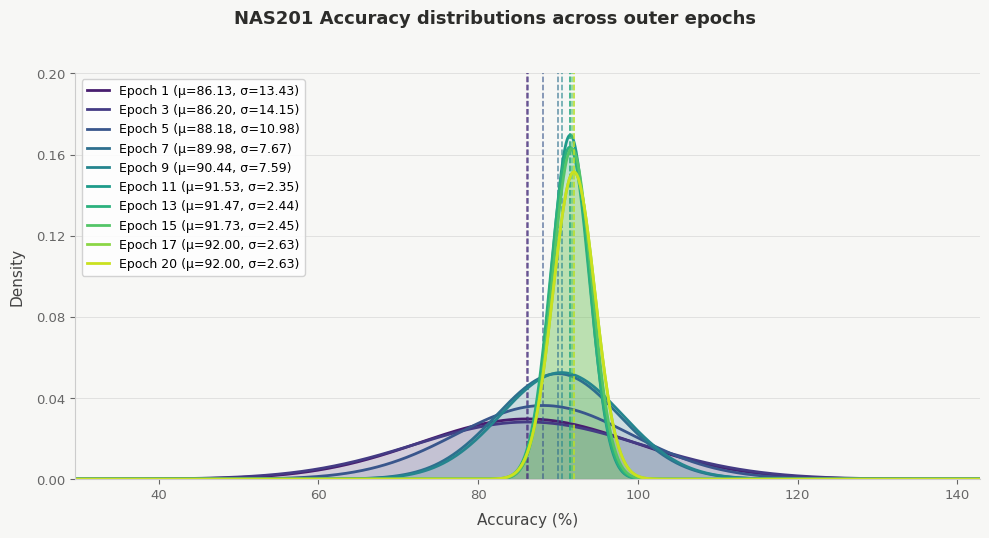

In [65]:
plot_history_gaussians(history,max_gaussians=10)

In [66]:
# ==================================================
# Test flow ripetuto su molte architetture a bassa accuracy
# PRESE DAL TEST DATASET
# ==================================================

import torch
import numpy as np
import pandas as pd

alpha_test = 0.5

n_tests = 100          # quante architetture testare
low_percent = 0.10     # prendo candidati dal 10% peggiore del test_dataset
seed = 42

model_VAE = model_VAE.to(DEVICE)
flow = flow.to(DEVICE)

model_VAE.eval()
flow.eval()

# --------------------------------------------------
# 1. Estraggo X e y dal test_dataset
# --------------------------------------------------
X_list = []
y_list = []

for i in range(len(test_dataset)):
    x, y = test_dataset[i]
    X_list.append(x.float())
    y_list.append(float(y))

X_all = torch.stack(X_list)
y_all = torch.tensor(y_list).float()

# Se le accuracy sono in percentuale, le porto in [0, 1]
if y_all.max() > 1.5:
    y_all = y_all / 100.0

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print(f"test_dataset acc min  = {y_all.min().item() * 100:.4f}%")
print(f"test_dataset acc mean = {y_all.mean().item() * 100:.4f}%")
print(f"test_dataset acc max  = {y_all.max().item() * 100:.4f}%")

# --------------------------------------------------
# 2. Seleziono n_tests architetture dal low_percent peggiore del test_dataset
# --------------------------------------------------
generator = torch.Generator().manual_seed(seed)

n_low = max(1, int(low_percent * len(y_all)))
sorted_idx = torch.argsort(y_all)
low_indices = sorted_idx[:n_low]

# se n_tests > n_low, campiono con replacement
if n_tests <= len(low_indices):
    perm = torch.randperm(len(low_indices), generator=generator)[:n_tests]
    test_indices = low_indices[perm]
else:
    rand_pos = torch.randint(
        low=0,
        high=len(low_indices),
        size=(n_tests,),
        generator=generator
    )
    test_indices = low_indices[rand_pos]

print(f"\nTesting {len(test_indices)} architectures from worst {low_percent * 100:.1f}% of test_dataset")
print(f"low pool size = {len(low_indices)}")

# --------------------------------------------------
# 3. Loop di test
# --------------------------------------------------
results = []

for t, idx_tensor in enumerate(test_indices):

    idx = idx_tensor.item()

    x_start = X_all[idx].unsqueeze(0).to(DEVICE).float()
    acc_start = y_all[idx].item()

    with torch.no_grad():
        # encode
        mu, logvar = model_VAE.encode(x_start)
        z_start = mu

        # flow
        direction = flow(z_start)
        z_new = z_start + alpha_test * direction

        # decode
        x_decoded = model_VAE.decode(z_new)

    x_decoded = x_decoded.squeeze(0).detach().cpu()

    generated_arch = decoded_x_to_nas201_arch(x_decoded)

    acc_generated, info_generated = query_nas201_accuracy(
        api=api,
        arch_str=generated_arch
    )

    if acc_generated is None:
        results.append({
            "test_id": t,
            "idx_test_dataset": idx,
            "acc_start": acc_start,
            "generated_arch": generated_arch,
            "acc_generated": None,
            "delta_acc": None,
            "improved": None,
            "direction_norm": direction.norm().item(),
        })
        continue

    acc_generated_norm = acc_generated / 100.0 if acc_generated > 1.5 else acc_generated
    delta_acc = acc_generated_norm - acc_start

    results.append({
        "test_id": t,
        "idx_test_dataset": idx,
        "acc_start": acc_start,
        "generated_arch": generated_arch,
        "acc_generated": acc_generated_norm,
        "delta_acc": delta_acc,
        "improved": delta_acc > 0,
        "direction_norm": direction.norm().item(),
    })

# --------------------------------------------------
# 4. Risultati in DataFrame
# --------------------------------------------------
df_results = pd.DataFrame(results)

df_valid = df_results.dropna(subset=["delta_acc"]).copy()

print("\n========== SUMMARY ON TEST DATASET ==========")
print(f"valid tests      = {len(df_valid)} / {len(df_results)}")
print(f"alpha            = {alpha_test}")
print(f"mean start acc   = {df_valid['acc_start'].mean() * 100:.4f}%")
print(f"mean gen acc     = {df_valid['acc_generated'].mean() * 100:.4f}%")
print(f"mean delta acc   = {df_valid['delta_acc'].mean() * 100:+.4f}%")
print(f"std delta acc    = {df_valid['delta_acc'].std() * 100:.4f}%")
print(f"min delta acc    = {df_valid['delta_acc'].min() * 100:+.4f}%")
print(f"max delta acc    = {df_valid['delta_acc'].max() * 100:+.4f}%")
print(f"success rate     = {df_valid['improved'].mean() * 100:.2f}%")

# --------------------------------------------------
# 5. Diversity delle architetture generate
# --------------------------------------------------
num_unique_generated = df_valid["generated_arch"].nunique()
diversity_generated = num_unique_generated / len(df_valid)

print(f"\nunique generated archs = {num_unique_generated} / {len(df_valid)}")
print(f"generated diversity    = {diversity_generated:.4f}")



X_all shape: torch.Size([3125, 96])
y_all shape: torch.Size([3125])
test_dataset acc min  = 10.0000%
test_dataset acc mean = 76.2457%
test_dataset acc max  = 88.9600%

Testing 100 architectures from worst 10.0% of test_dataset
low pool size = 312

========== SUMMARY ON TEST DATASET ==========
valid tests      = 100 / 100
alpha            = 0.5
mean start acc   = 47.6780%
mean gen acc     = 79.7452%
mean delta acc   = +32.0672%
std delta acc    = 24.2299%
min delta acc    = -50.9900%
max delta acc    = +83.1250%
success rate     = 92.00%

unique generated archs = 94 / 100
generated diversity    = 0.9400


In [67]:
num_unique_generated = df_valid["generated_arch"].nunique()
diversity_generated = num_unique_generated / len(df_valid)

print(f"unique generated archs = {num_unique_generated} / {len(df_valid)}")
print(f"generated diversity    = {diversity_generated:.4f}")

unique generated archs = 94 / 100
generated diversity    = 0.9400
